# BTC Market Analysis
Analisis faktor-faktor (macro, micro, siklus halving) yang mempengaruhi pergerakan harga Bitcoin, dengan tujuan memahami pola pergerakan pasar — bukan memprediksi harga secara presisi.

**Struktur notebook:**
1. Pengumpulan data harga
2. Feature engineering (siklus halving)
3. Data macro (suku bunga, dst)
4. Exploratory Data Analysis
5. Modeling (regime classification)

## 1. Import Libraries
`yfinance` untuk narik data harga BTC historis, `pandas` untuk manipulasi data tabular.

In [1]:
import yfinance as yf
import pandas as pd

## 2. Download Data Harga BTC
Ambil data harian BTC-USD dari Yahoo Finance mulai September 2014 (batas awal data yang tersedia gratis tanpa API key). Mencakup 3 siklus halving penuh (2016, 2020, 2024).

In [2]:
btc = yf.download("BTC-USD", start="2014-09-01", end=None)
btc = btc.reset_index()

[*********************100%***********************]  1 of 1 completed


## 3. Bersihkan Struktur Kolom
yfinance versi terbaru mengembalikan kolom dalam format MultiIndex meski cuma 1 ticker — diratakan supaya lebih mudah diproses di tahap selanjutnya.

In [3]:
btc.columns = btc.columns.get_level_values(0)
btc.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


## 4. Data Quality Check
Pastikan tidak ada nilai kosong (NaN) sebelum dipakai untuk analisis lebih lanjut.

In [4]:
btc.info()
btc.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4385 entries, 0 to 4384
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    4385 non-null   datetime64[s]
 1   Close   4385 non-null   float64      
 2   High    4385 non-null   float64      
 3   Low     4385 non-null   float64      
 4   Open    4385 non-null   float64      
 5   Volume  4385 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 205.7 KB


Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 5. Simpan ke CSV
Simpan hasil bersih ke `data/btc_price.csv` supaya tidak perlu narik ulang dari API tiap kali notebook dijalankan.

In [5]:
btc.to_csv("../data/btc_price.csv", index=False)

## 6. Visualisasi Awal
Plot harga dalam log scale (karena rentang harga BTC sangat lebar, dari puluhan dolar ke puluhan ribu) untuk lihat tren jangka panjang.

<Axes: title={'center': 'BTC Price History'}, xlabel='Date'>

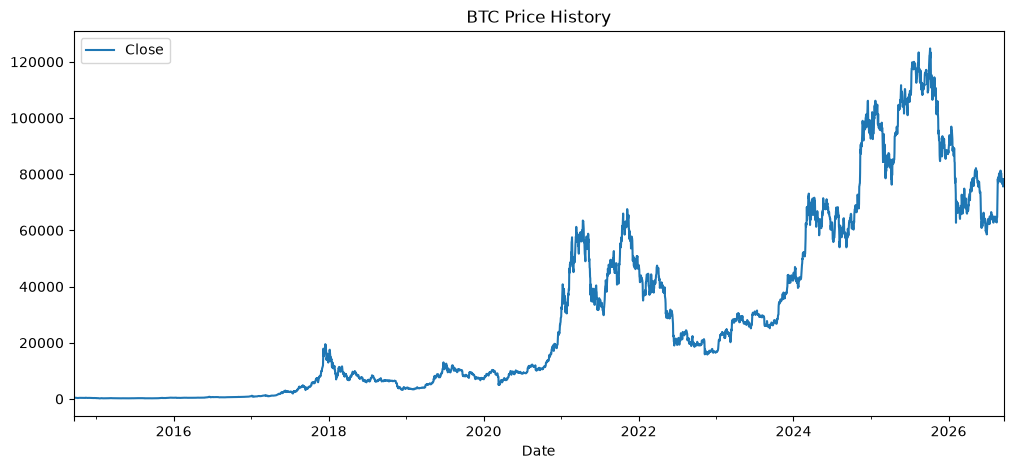

In [6]:
btc.plot(x="Date", y="Close", figsize=(12, 5), title="BTC Price History")

## 7. Tandai Siklus Halving
Tambahkan kolom jumlah hari sejak halving terakhir — dipakai nanti sebagai salah satu fitur untuk analisis pola siklus.

In [7]:
import datetime

halving_dates = [
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
]
halving_dates = [pd.to_datetime(d) for d in halving_dates]

def days_since_halving(date):
    past_halvings = [h for h in halving_dates if h <= date]
    if not past_halvings:
        return None
    last_halving = max(past_halvings)
    return (date - last_halving).days

btc["days_since_halving"] = btc["Date"].apply(days_since_halving)
btc.head()

Price,Date,Close,High,Low,Open,Volume,days_since_halving
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,658
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,659
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,660
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,661
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,662


## 8. Visualisasi dengan Marker Halving
Plot ulang harga BTC dengan garis vertikal di tiap tanggal halving, supaya bisa dilihat secara visual apakah ada pola pergerakan harga di sekitar event ini.

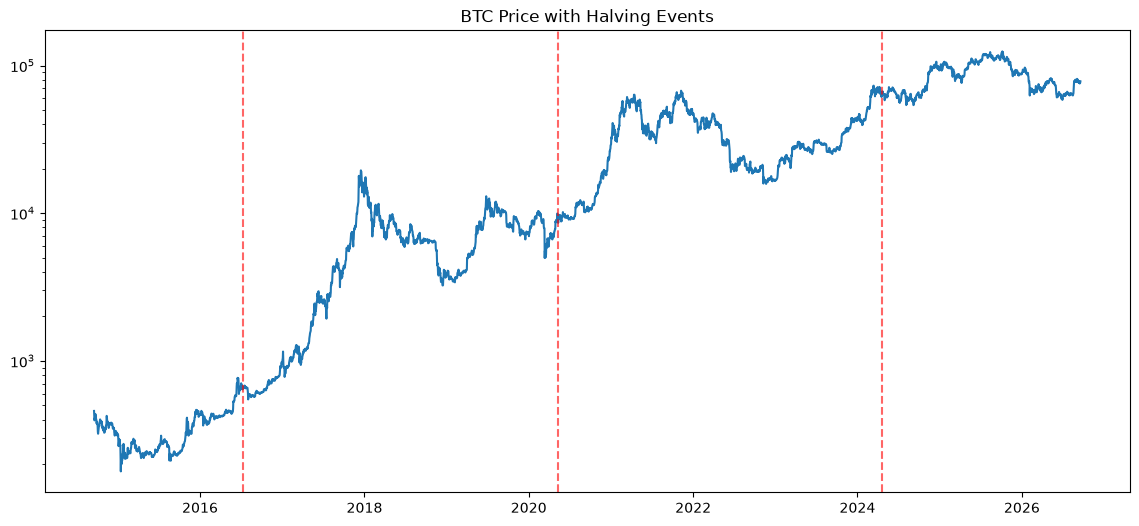

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc["Date"], btc["Close"])

for h in halving_dates:
    if h >= btc["Date"].min():
        ax.axvline(h, color="red", linestyle="--", alpha=0.6)

ax.set_title("BTC Price with Halving Events")
ax.set_yscale("log")  # log scale penting, karena range harga BTC dari puluhan ke puluhan ribu USD
plt.show()

## 9. Simpan Ulang Data dengan Kolom Halving
Update file CSV supaya menyertakan kolom `days_since_halving` yang baru ditambahkan, agar tidak perlu menghitung ulang setiap kali notebook dibuka.

In [9]:
btc.to_csv("../data/btc_price.csv", index=False)

## 10. Ambil Data Macro: Suku Bunga Fed (FRED)
Menarik data Federal Funds Effective Rate dari FRED API — indikator kebijakan moneter utama yang biasanya berkorelasi dengan pergerakan aset risk-on seperti BTC.

In [10]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv("../.env")
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

fed_rate = fred.get_series("DFF")
fed_rate = fed_rate.reset_index()
fed_rate.columns = ["Date", "fed_rate"]
fed_rate.head()

,Date,fed_rate
0,1954-07-01,1.13
1,1954-07-02,1.25
2,1954-07-03,1.25
3,1954-07-04,1.25
4,1954-07-05,0.88


## 11. Cek Rentang Tanggal Data Fed Rate
Memastikan data suku bunga Fed cukup panjang untuk mencakup seluruh rentang data harga BTC (sejak 2014).

In [11]:
fed_rate["Date"].min(), fed_rate["Date"].max()

(Timestamp('1954-07-01 00:00:00'), Timestamp('2026-09-16 00:00:00'))

## 12. Samakan Tipe Data Tanggal
`yfinance` dan `fredapi` menghasilkan presisi datetime yang berbeda, sehingga perlu disamakan secara eksplisit sebelum data bisa digabungkan.

In [12]:
btc["Date"] = btc["Date"].astype("datetime64[ns]")
fed_rate["Date"] = fed_rate["Date"].astype("datetime64[ns]")
print(btc["Date"].dtype)
print(fed_rate["Date"].dtype)

datetime64[ns]
datetime64[ns]


## 13. Gabungkan Data Harga BTC dengan Suku Bunga Fed
Menggunakan `merge_asof` karena data suku bunga Fed hanya berubah sesekali (bukan harian seperti harga BTC) — setiap tanggal BTC akan diisi dengan nilai suku bunga terakhir yang berlaku (backward-fill by date).

In [13]:
btc_merged = pd.merge_asof(
    btc.sort_values("Date"),
    fed_rate.sort_values("Date"),
    on="Date",
    direction="backward"
)
btc_merged.head()

,Date,Close,High,Low,Open,Volume,days_since_halving,fed_rate
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,658,0.09
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,659,0.09
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,660,0.09
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,661,0.09
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,662,0.09


## 14. Data Quality Check Setelah Merge
Pastikan tidak ada nilai kosong pada kolom `fed_rate` setelah proses penggabungan.

In [14]:
btc_merged.isna().sum()

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
days_since_halving    0
fed_rate              0
dtype: int64

## 15. Simpan Data Gabungan
Menyimpan dataset gabungan (harga BTC + suku bunga Fed + siklus halving) ke file terpisah agar versi data mentah tetap terjaga.

In [15]:
btc_merged.to_csv("../data/btc_with_macro.csv", index=False)

## 16. Ambil Data Macro: Dollar Index (DXY)
Menarik data indeks kekuatan dolar AS dari FRED — indikator yang sering berkorelasi terbalik dengan aset risk-on seperti BTC (dolar kuat cenderung menekan harga aset berisiko).

In [16]:
dxy = fred.get_series("DTWEXBGS")  # Trade Weighted U.S. Dollar Index: Broad, Goods and Services
dxy = dxy.reset_index()
dxy.columns = ["Date", "dxy"]
dxy.head()

,Date,dxy
0,2006-01-02,101.4155
1,2006-01-03,100.7558
2,2006-01-04,100.2288
3,2006-01-05,100.2992
4,2006-01-06,100.0241


## 17. Samakan Tipe Data Tanggal (DXY)
Menyamakan presisi datetime sebelum digabungkan dengan dataset utama, sama seperti proses sebelumnya untuk Fed rate.

In [17]:
dxy["Date"] = dxy["Date"].astype("datetime64[ns]")
print(dxy["Date"].dtype)

datetime64[ns]


## 18. Bersihkan Baris Kosong pada Data DXY
FRED menyimpan baris dengan nilai kosong (NaN) pada hari libur nasional AS, bukan melewatkan tanggalnya. Baris ini dibuang sebelum merge agar `merge_asof` benar-benar mundur ke hari kerja terakhir yang valid, bukan ikut mengambil baris kosong di tanggal libur tersebut.

In [18]:
dxy_clean = dxy.dropna(subset=["dxy"])

## 19. Bangun Ulang Dataset Gabungan (Harga + Fed Rate + DXY)
Membangun ulang dari data harga BTC mentah untuk memastikan tidak ada sisa data yang salah dari proses merge sebelumnya.

In [19]:
btc_merged = pd.merge_asof(
    btc.sort_values("Date"),
    fed_rate.sort_values("Date"),
    on="Date",
    direction="backward"
)
btc_merged = pd.merge_asof(
    btc_merged.sort_values("Date"),
    dxy_clean.sort_values("Date"),
    on="Date",
    direction="backward"
)
btc_merged.isna().sum()

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
days_since_halving    0
fed_rate              0
dxy                   0
dtype: int64

## 20. Simpan Dataset Gabungan Final

In [20]:
btc_merged.to_csv("../data/btc_with_macro.csv", index=False)

## 21. Load Dataset Final untuk EDA

In [21]:
df = pd.read_csv("../data/btc_with_macro.csv", parse_dates=["Date"])
df.head()

,Date,Close,High,Low,Open,Volume,days_since_halving,fed_rate,dxy
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,658,0.09,95.9106
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,659,0.09,96.1284
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,660,0.09,96.3417
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,661,0.09,96.3417
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,662,0.09,96.3417


## 22. Cek Korelasi Antar Variabel
Melihat seberapa kuat hubungan linear antara harga BTC dengan Fed rate, DXY, dan hari sejak halving. Korelasi bukan berarti sebab-akibat, tapi ini titik awal untuk melihat variabel mana yang paling layak digali lebih dalam.

In [22]:
corr = df[["Close", "fed_rate", "dxy", "days_since_halving"]].corr()
corr

,Close,fed_rate,dxy,days_since_halving
Close,1.000000,0.599906,0.578042,-0.249795
fed_rate,0.599906,1.000000,0.683258,0.155517
dxy,0.578042,0.683258,1.000000,-0.036383
days_since_halving,-0.249795,0.155517,-0.036383,1.000000


## 23. Visualisasikan Korelasi (Heatmap)

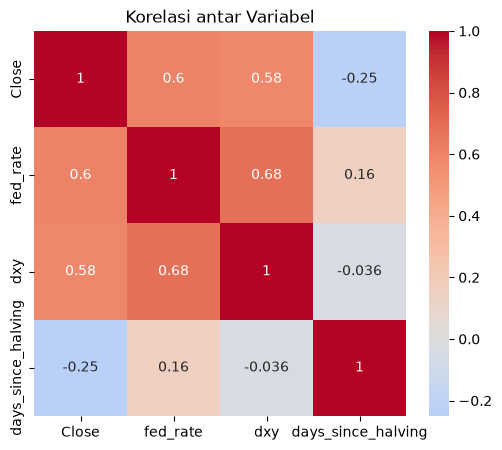

In [23]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Korelasi antar Variabel")
plt.show()

## 24. Korelasi dengan Percentage Change (Menghindari Spurious Correlation)
Variabel level (harga, suku bunga, indeks) cenderung memiliki tren jangka panjang yang membuat korelasi mentah menyesatkan. Menghitung perubahan harian (% change) membuat data lebih stasioner, sehingga korelasi yang muncul lebih mencerminkan hubungan nyata, bukan sekadar dua hal yang sama-sama trending.

In [24]:
df_pct = df[["Close", "fed_rate", "dxy"]].pct_change().dropna()
df_pct.columns = ["close_pct", "fed_rate_pct", "dxy_pct"]

corr_pct = df_pct.corr()
corr_pct

,close_pct,fed_rate_pct,dxy_pct
close_pct,1.000000,-0.015110,-0.091604
fed_rate_pct,-0.015110,1.000000,0.006652
dxy_pct,-0.091604,0.006652,1.000000


## 25. Visualisasikan Korelasi (% Change)

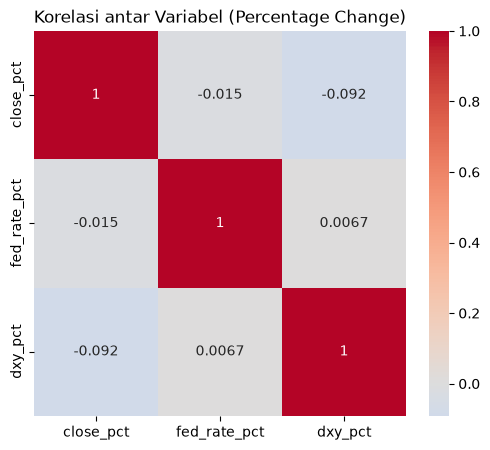

In [25]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_pct, annot=True, cmap="coolwarm", center=0)
plt.title("Korelasi antar Variabel (Percentage Change)")
plt.show()

## 26. Interpretasi: Korelasi Level vs Percentage Change (Berdasarkan Riset)
Korelasi pada data level menunjukkan hubungan kuat, namun ini adalah spurious correlation akibat tren jangka panjang yang searah. Setelah dihitung dari percentage change, korelasi turun drastis mendekati nol.

Temuan ini konsisten dengan penelitian Federal Reserve Bank of New York (Benigno & Rosa, 2023), yang menemukan bahwa Bitcoin secara sistematis tidak merespons berita moneter dan makroekonomi AS, berbeda dari kelas aset lain (emas, S&P 500, nilai tukar) yang meresponsnya secara signifikan.

Riset S&P Global (2023) menemukan korelasi Bitcoin dengan yield Treasury 2 tahun sebesar -0.33 pada frekuensi bulanan sejak 2017 — mengindikasikan hubungan macro-BTC mungkin lebih terlihat pada frekuensi rendah dibanding harian. Riset FTSE Russell/LSEG juga mencatat bahwa harga Bitcoin cenderung bergerak mendahului perubahan suku bunga Fed, mencerminkan reaksi terhadap ekspektasi pasar, bukan pengumuman resmi — yang turut menjelaskan mengapa uji lag positif (macro mendahului harga) tidak menemukan hubungan signifikan.

## 27. Cek Korelasi dengan Time Lag
Menguji apakah perubahan DXY dan Fed rate di hari-hari sebelumnya lebih berkorelasi dengan pergerakan harga BTC hari ini, dibanding perubahan di hari yang sama (lag 0). Ini untuk menguji dugaan bahwa efek macro terhadap harga bersifat delayed, bukan instan.

In [26]:
lags = [1, 3, 7, 14, 30]
lag_results = {}

for lag in lags:
    temp = pd.DataFrame({
        "close_pct": df_pct["close_pct"],
        "dxy_pct_lag": df_pct["dxy_pct"].shift(lag),
        "fed_rate_pct_lag": df_pct["fed_rate_pct"].shift(lag)
    }).dropna()
    
    lag_results[lag] = {
        "dxy_corr": temp["close_pct"].corr(temp["dxy_pct_lag"]),
        "fed_rate_corr": temp["close_pct"].corr(temp["fed_rate_pct_lag"])
    }

lag_df = pd.DataFrame(lag_results).T
lag_df.index.name = "lag_days"
lag_df

,dxy_corr,fed_rate_corr
lag_days,,
1,0.031144,-0.005140
3,0.004071,-0.023730
7,0.008150,0.024285
14,-0.003291,0.001760
30,-0.003414,0.000589


## 28. Visualisasikan Korelasi per Lag

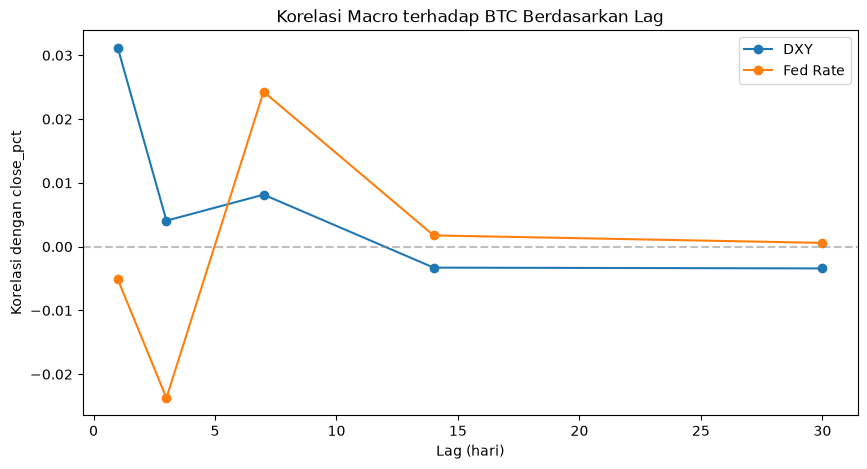

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(lag_df.index, lag_df["dxy_corr"], marker="o", label="DXY")
plt.plot(lag_df.index, lag_df["fed_rate_corr"], marker="o", label="Fed Rate")
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Lag (hari)")
plt.ylabel("Korelasi dengan close_pct")
plt.title("Korelasi Macro terhadap BTC Berdasarkan Lag")
plt.legend()
plt.show()

## 29. Interpretasi: Analisis Lag (Berdasarkan Riset)
Pengujian korelasi dengan lag 1, 3, 7, 14, dan 30 hari tidak menunjukkan pola yang konsisten — seluruh nilai korelasi berada dalam rentang -0.024 hingga 0.031, yang secara statistik praktis nol.

Temuan ini sejalan dengan riset FTSE Russell/LSEG, yang mencatat bahwa harga Bitcoin cenderung bergerak *mendahului* perubahan suku bunga Fed (mencerminkan reaksi terhadap ekspektasi pasar), bukan mengikuti setelahnya — sehingga uji lag yang mencari efek macro *sebelum* harga bergerak (seperti yang dilakukan di sini) secara teori memang tidak akan menemukan hubungan signifikan.

Riset NY Fed (Benigno & Rosa, 2023) juga menemukan bahwa respons Bitcoin terhadap berita moneter tetap tidak signifikan bahkan pada jendela waktu intraday (30 menit hingga 1 jam), memperkuat kesimpulan bahwa disconnect ini bukan sekadar keterbatasan frekuensi data harian, melainkan karakteristik Bitcoin yang secara konsisten teramati di berbagai skala waktu.

## 30. Analisis Return Berdasarkan Fase Siklus Halving
Membagi data menjadi 4 periode siklus halving, lalu menghitung return rata-rata di tiap fase untuk melihat apakah ada pola pergerakan harga yang konsisten pada titik tertentu dalam siklus (misal: apakah harga cenderung naik di tahun kedua setelah halving?).

In [28]:
df["halving_cycle"] = pd.cut(
    df["days_since_halving"],
    bins=[-1, 365, 730, 1095, 1460],
    labels=["Tahun 1", "Tahun 2", "Tahun 3", "Tahun 4"]
)

df["close_pct_daily"] = df["Close"].pct_change()

cycle_stats = df.groupby("halving_cycle", observed=True)["close_pct_daily"].agg(
    ["mean", "std", "count"]
)
cycle_stats["annualized_return_pct"] = cycle_stats["mean"] * 365 * 100
cycle_stats

,mean,std,count,annualized_return_pct
halving_cycle,,,,
Tahun 1,0.003655,0.030883,1098,133.400009
Tahun 2,0.000819,0.040600,1167,29.899114
Tahun 3,0.000964,0.032636,1246,35.184215
Tahun 4,0.001856,0.033071,873,67.746472


## 31. Visualisasikan Return per Fase Siklus

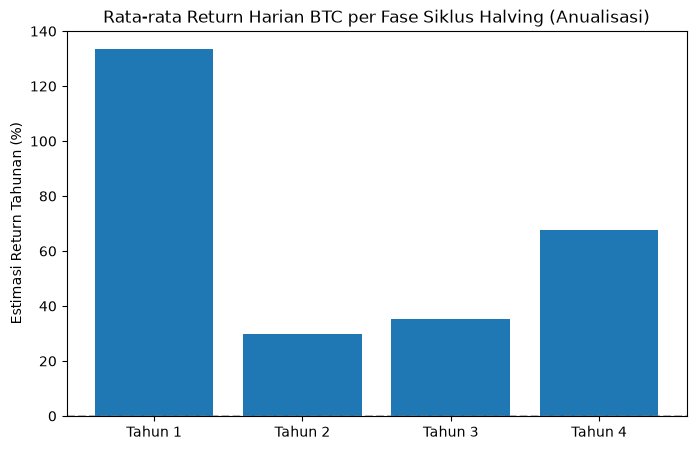

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(cycle_stats.index, cycle_stats["annualized_return_pct"])
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.ylabel("Estimasi Return Tahunan (%)")
plt.title("Rata-rata Return Harian BTC per Fase Siklus Halving (Anualisasi)")
plt.show()

## 32. Interpretasi: Return per Fase Siklus Halving
Pola return tertinggi di Tahun 1 (pasca-halving) konsisten dengan dokumentasi historis pasar: setiap halving (2012, 2016, 2020, 2024) diikuti rally signifikan pada 12-18 bulan pertama. Namun, pola ini menunjukkan "diminishing returns" — setiap siklus menghasilkan multiplier yang mengecil (2012: ~100x, 2016: ~30x, 2020: ~8x, 2024: jauh lebih kecil lagi), seiring pasar Bitcoin yang semakin matang dan basis market cap yang semakin besar.

Return tinggi di Tahun 4 kemungkinan besar mencerminkan fase antisipasi menjelang halving berikutnya (sentimen bullish pra-halving), bukan efek langsung dari halving sebelumnya.

**Catatan metodologis penting:** analisis ini hanya mencakup 3 siklus halving penuh — sample size yang sangat kecil secara statistik, sehingga generalisasi pola ini sebagai "hukum pasti" tidak tepat. Analis pasar mencatat bahwa siklus 2024 berkorelasi lebih erat dengan kondisi likuiditas global dan kebijakan Fed dibanding dengan halving itu sendiri — mengindikasikan bahwa efek halving semakin bercampur dengan faktor macro seiring waktu, bukan berdiri sendiri sebagai variabel independen.

## 33. Breakdown Return per Siklus Halving Secara Individual
Data sebelumnya menggabungkan seluruh siklus (2016, 2020, 2024) menjadi satu rata-rata per fase tahun. Di sini, tiap siklus dipecah individual untuk melihat apakah pola "Tahun 1 tinggi" konsisten di semua siklus, atau didominasi oleh satu-dua siklus tertentu.

In [30]:
df["cycle_start"] = df["Date"].apply(
    lambda d: max([h for h in halving_dates if h <= d])
)

cycle_year_stats = df.groupby(
    ["cycle_start", "halving_cycle"], observed=True
)["close_pct_daily"].agg(["mean", "count"])

cycle_year_stats["annualized_return_pct"] = cycle_year_stats["mean"] * 365 * 100
cycle_year_stats

mean  count  annualized_return_pct
cycle_start halving_cycle                                        
2012-11-28  Tahun 2       -0.002005     72             -73.178573
            Tahun 3        0.000497    365              18.129554
            Tahun 4        0.003272    223             119.414975
2016-07-09  Tahun 1        0.004108    366             149.925183
            Tahun 2        0.004175    365             152.377853
            Tahun 3        0.002356    365              85.998979
            Tahun 4       -0.000241    306              -8.790432
2020-05-11  Tahun 1        0.005715    366             208.605093
            Tahun 2       -0.001100    365             -40.158359
            Tahun 3        0.000282    365              10.293089
            Tahun 4        0.002804    344             102.334310
2024-04-20  Tahun 1        0.001142    366              41.669751
            Tahun 2       -0.000060    365              -2.189019
            Tahun 3        0.000377    151              13.745956

## 34. Visualisasikan Perbandingan Return Antar Siklus

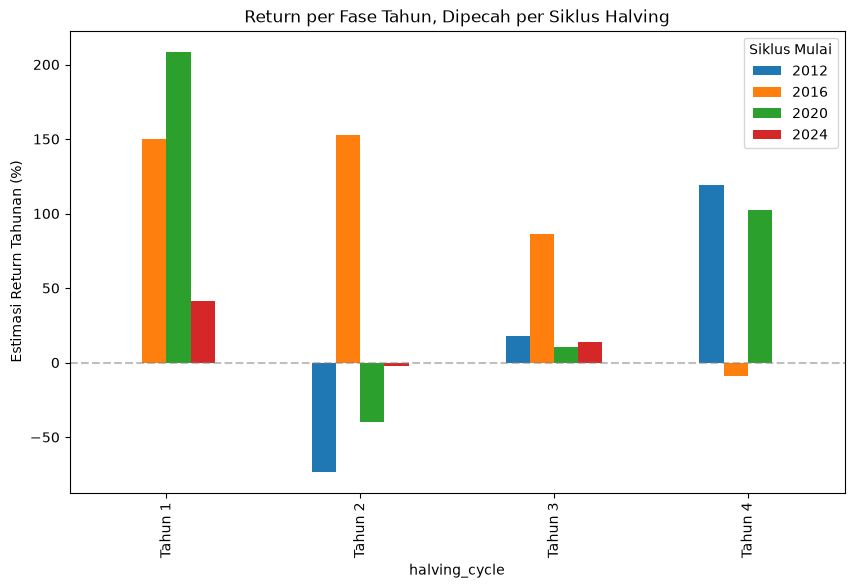

In [31]:
pivot = cycle_year_stats["annualized_return_pct"].unstack(level=0)
pivot.columns = [d.strftime("%Y") for d in pivot.columns]

pivot.plot(kind="bar", figsize=(10, 6))
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.ylabel("Estimasi Return Tahunan (%)")
plt.title("Return per Fase Tahun, Dipecah per Siklus Halving")
plt.legend(title="Siklus Mulai")
plt.show()

## 35. Interpretasi: Breakdown per Siklus Individual
Breakdown per siklus menunjukkan variasi yang jauh lebih besar dari yang terlihat pada grafik gabungan sebelumnya. Tahun 1 relatif konsisten positif di semua siklus (42% hingga 209%), namun Tahun 2-4 menunjukkan arah yang saling bertentangan antar siklus (contoh: Tahun 2 berkisar dari -73% hingga +152%).

Ini menunjukkan bahwa rata-rata gabungan pada analisis sebelumnya menyembunyikan variasi asli yang signifikan — sebuah bentuk lain dari risiko agregasi data yang menyesatkan, serupa dengan kasus spurious correlation pada analisis macro. Dengan hanya 3-4 siklus yang tersedia (dan 2 di antaranya tidak lengkap karena keterbatasan rentang data), generalisasi pola tahunan dalam siklus halving tidak dapat dilakukan secara statistik andal.

Variasi antar siklus ini sejalan dengan catatan analis pasar bahwa tiap siklus memiliki konteks struktural berbeda (ICO boom 2017, stimulus COVID 2020-2021, ETF demand 2024) — mengindikasikan bahwa faktor eksternal per periode kemungkinan lebih berpengaruh terhadap bentuk siklus dibanding halving itu sendiri sebagai mekanisme tunggal.